In [1]:
# Import necessary libraries
import pandas as pd

In [2]:
# Load the banknote dataset 
df = pd.read_csv("data/banknote_dataset.csv")
X = df[["variance", "skewness"]]
y = df["class"]

df.head()


,variance,skewness,class
0,3.62160,8.6661,0.0
1,4.54590,8.1674,0.0
2,3.86600,-2.6383,0.0
3,3.45660,9.5228,0.0
4,0.32924,-4.4552,0.0


In [3]:
# import necessary libraries and split data for training and testing/evaluation
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size = .2, random_state=42)


[]

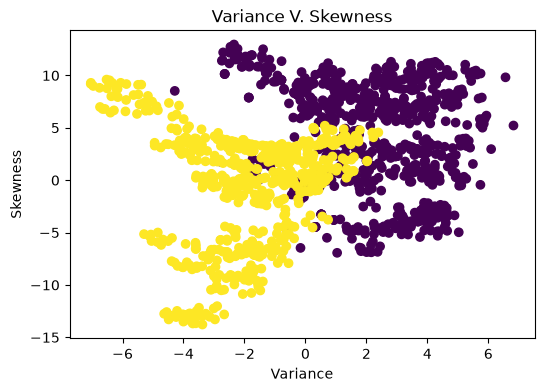

In [4]:
# Visualize the data (first two features)
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))

plt.scatter(X["variance"], X["skewness"], cmap = "viridis", c = y)
plt.xlabel("Variance")
plt.ylabel("Skewness")
plt.title("Variance V. Skewness")
plt.plot()

In [5]:
# Train SVM classifier
from sklearn.svm import SVC
model = SVC(kernel="rbf")
model.fit(x_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [6]:
# Evaluate the performance of the model
y_pred = model.predict(x_test)
y_pred_train = model.predict(x_train)

[]

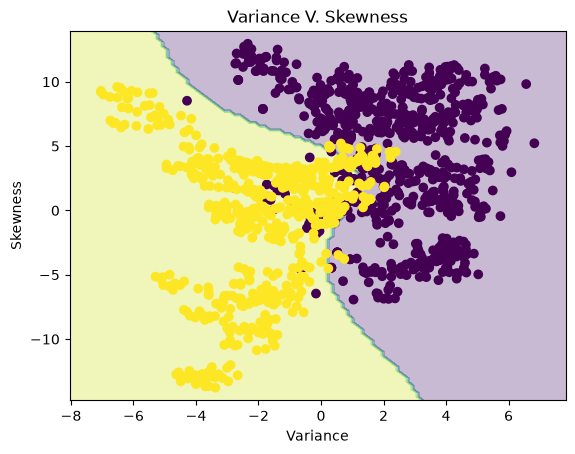

In [7]:
# Plot decision boundary
from sklearn.inspection import DecisionBoundaryDisplay
disp = DecisionBoundaryDisplay.from_estimator(
    model, X, response_method="predict", alpha=.3
)

plt.scatter(X["variance"], X["skewness"], cmap = "viridis", c = y)
plt.xlabel("Variance")
plt.ylabel("Skewness")
plt.title("Variance V. Skewness")
plt.plot()

In [8]:
# Print accuracy score
from sklearn.metrics import accuracy_score, classification_report
# really close accurates show that the model isn't overfitted
print(accuracy_score(y_test, y_pred)) 
accuracy_score(y_train, y_pred_train)

0.9127272727272727


0.9288969917958068

In [9]:
# Print classification report
print(classification_report(y_train, y_pred_train))
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.95      0.93      0.94       614
         1.0       0.91      0.93      0.92       483

    accuracy                           0.93      1097
   macro avg       0.93      0.93      0.93      1097
weighted avg       0.93      0.93      0.93      1097

              precision    recall  f1-score   support

         0.0       0.90      0.95      0.92       148
         1.0       0.93      0.87      0.90       127

    accuracy                           0.91       275
   macro avg       0.92      0.91      0.91       275
weighted avg       0.91      0.91      0.91       275

